# Stroke Prediction — Exploratory Data Analysis

We explore a healthcare stroke dataset (~5,110 patients) to understand which demographic, lifestyle, and clinical features correlate with stroke incidence.

**Dataset**: 5,110 patient records with 11 input features (demographic, lifestyle, clinical) and a binary `stroke` target. Severe class imbalance — only ~4.9% of patients had a stroke.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

## 2. Load Data

In [2]:
df = pd.read_csv("data/stroke.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.describe(include='all').round(3)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000,5110,5110.000,5110.000,5110.000,5110,5110,5110,5110.000,4909.000,5110,5110.000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829,NaN,43.227,0.097,0.054,NaN,NaN,NaN,106.148,28.893,NaN,0.049
std,21161.722,NaN,22.613,0.297,0.226,NaN,NaN,NaN,45.284,7.854,NaN,0.215
min,67.000,NaN,0.080,0.000,0.000,NaN,NaN,NaN,55.120,10.300,NaN,0.000
25%,17741.250,NaN,25.000,0.000,0.000,NaN,NaN,NaN,77.245,23.500,NaN,0.000
50%,36932.000,NaN,45.000,0.000,0.000,NaN,NaN,NaN,91.885,28.100,NaN,0.000
75%,54682.000,NaN,61.000,0.000,0.000,NaN,NaN,NaN,114.090,33.100,NaN,0.000


In [5]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Unique IDs     : {df['id'].nunique()}")

Duplicate rows : 0
Unique IDs     : 5110


## 4. Missing / Invalid Values

Missing values:
bmi    201
dtype: int64


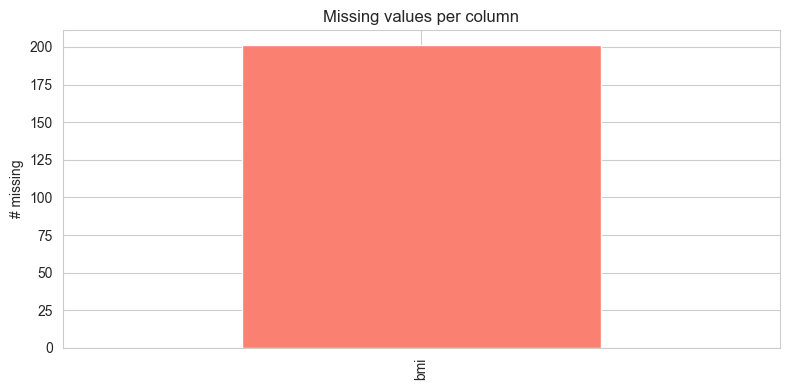

In [6]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing>0])

# Visualize
plt.figure(figsize=(8, 4))
missing[missing>0].plot(kind="bar", color="salmon")
plt.title("Missing values per column")
plt.ylabel("# missing"); plt.tight_layout(); plt.show()

## 5. Target Variable Distribution

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_70282/4201146592.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="stroke", data=df, palette="Set2", ax=axes[0], order=[0, 1])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_70282/4201146592.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Stroke (0)", "Stroke (1)"])


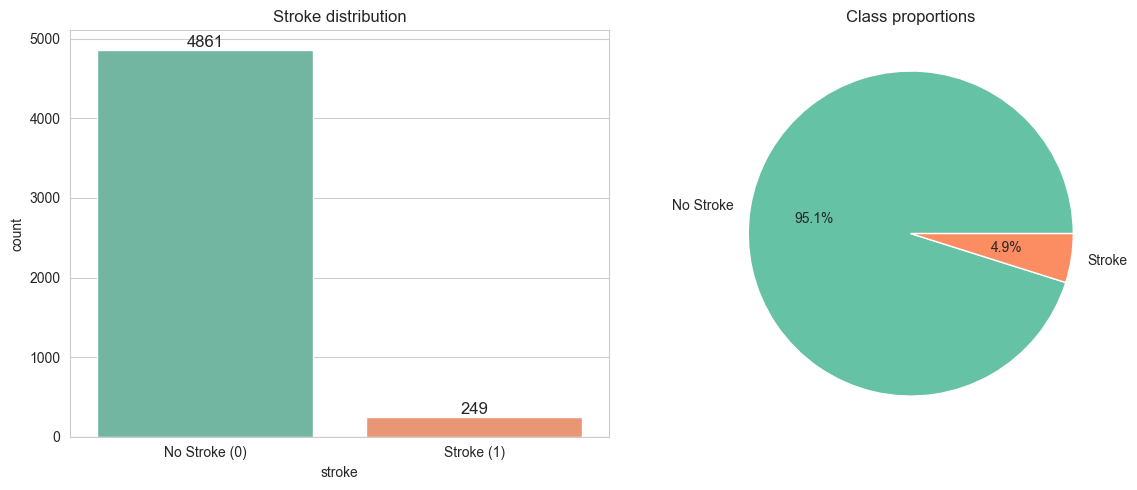

Stroke rate: 4.87%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="stroke", data=df, palette="Set2", ax=axes[0], order=[0, 1])
axes[0].set_xticklabels(["No Stroke (0)", "Stroke (1)"])
axes[0].set_title("Stroke distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)

df["stroke"].value_counts().plot.pie(
    labels=["No Stroke","Stroke"], autopct="%1.1f%%",
    colors=["#66c2a5","#fc8d62"], ax=axes[1])
axes[1].set_ylabel(""); axes[1].set_title("Class proportions")
plt.tight_layout(); plt.show()
print(f"Stroke rate: {df['stroke'].mean()*100:.2f}%")

## 6. Univariate — Numeric Feature Distributions

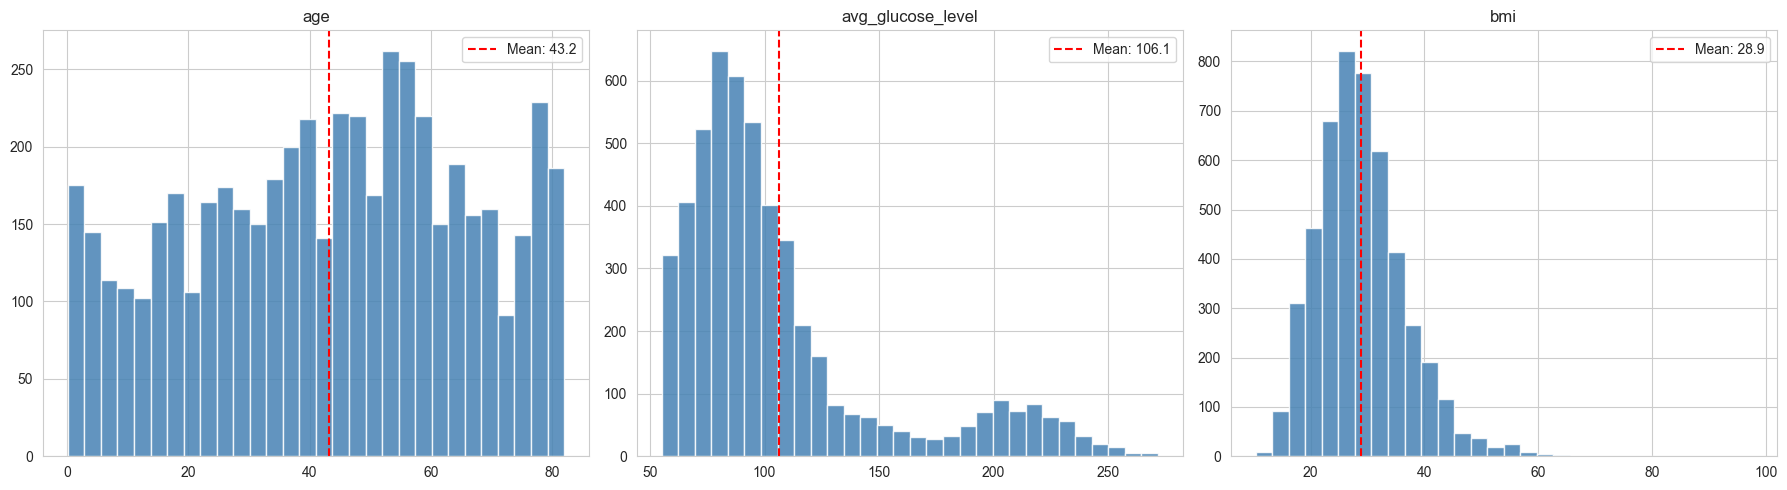

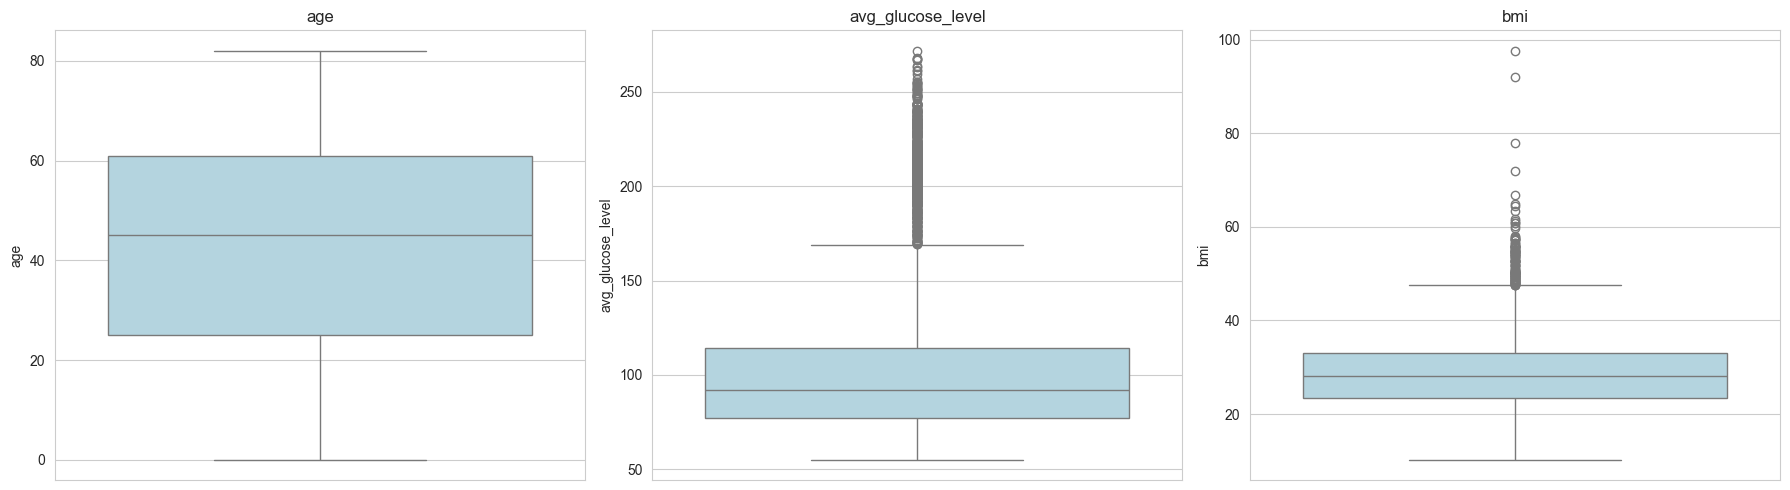

In [8]:
num_features = ["age", "avg_glucose_level", "bmi"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    df[col].dropna().hist(bins=30, color="steelblue", edgecolor="white",
                          alpha=0.85, ax=axes[i])
    axes[i].axvline(df[col].mean(), color="red", linestyle="--",
                    label=f"Mean: {df[col].mean():.1f}")
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

# Box plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col)
plt.tight_layout(); plt.show()

## 7. Univariate — Categorical Distributions

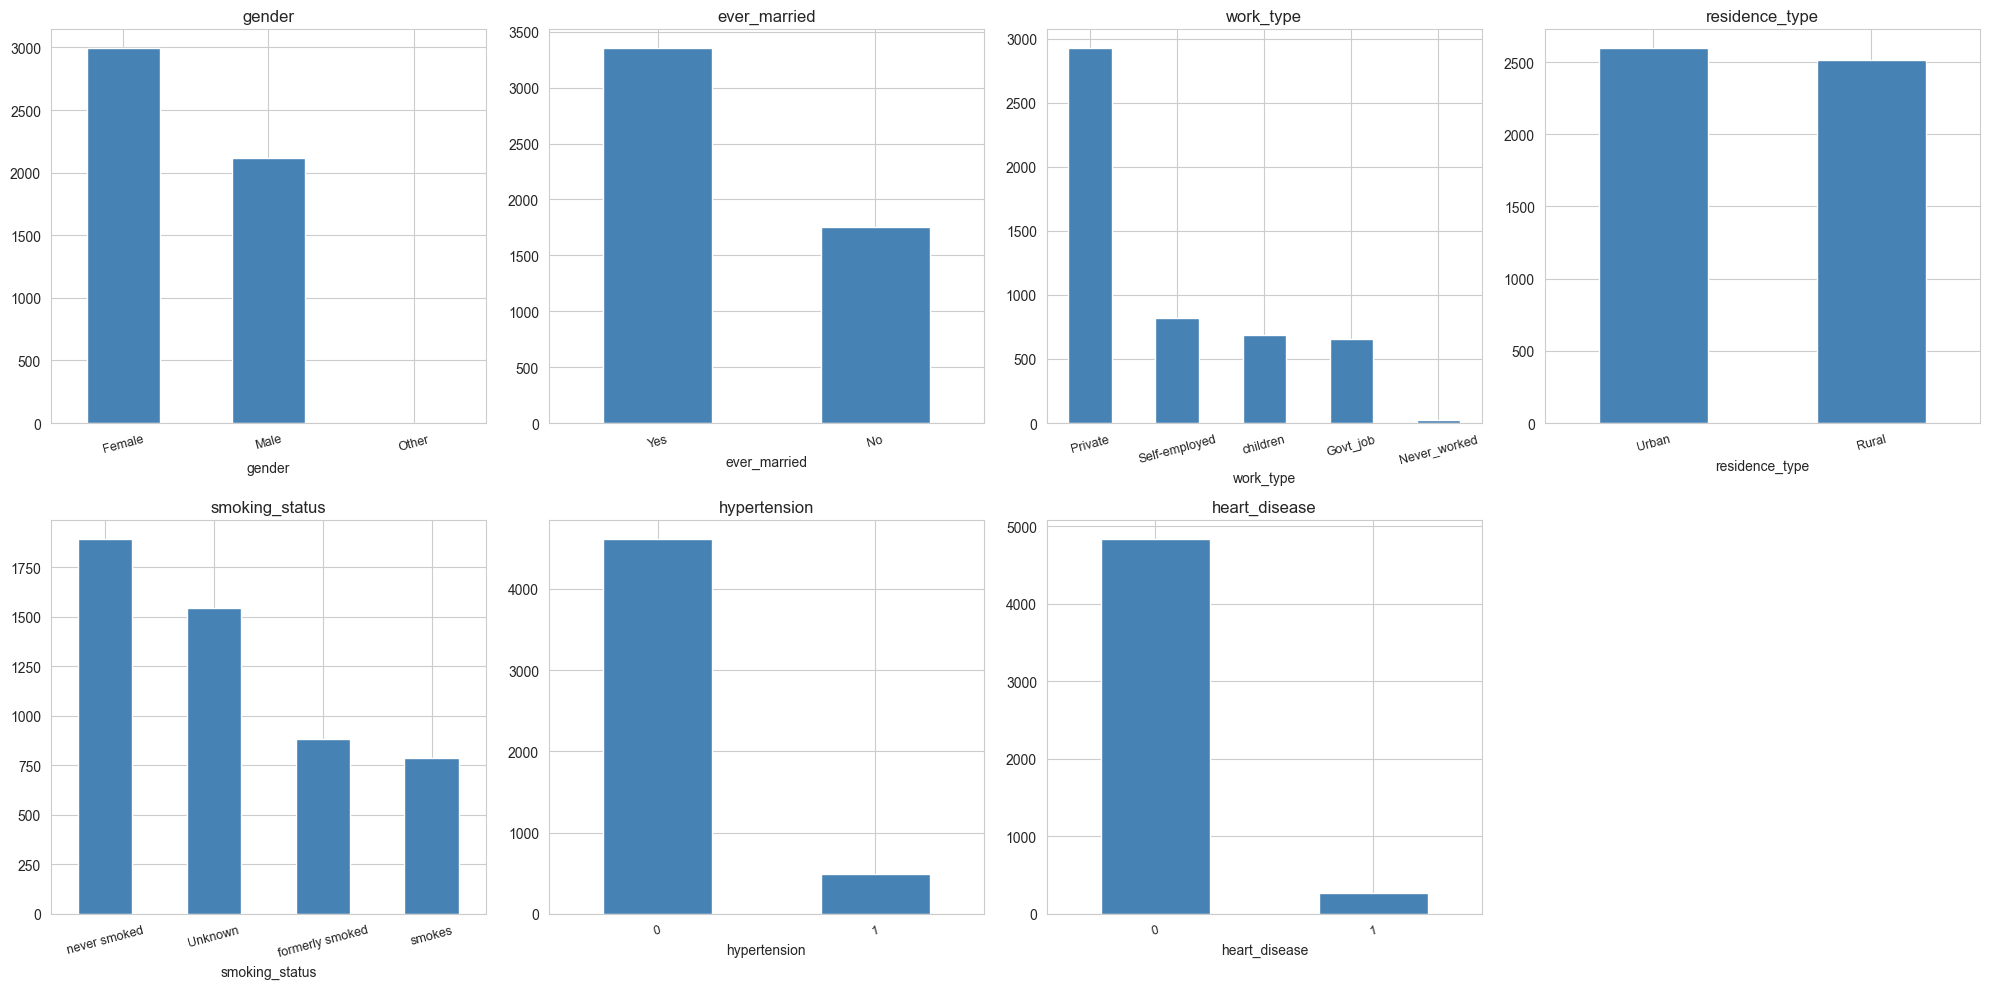

In [9]:
cat_features = ["gender", "ever_married", "work_type", "residence_type", "smoking_status",
                "hypertension", "heart_disease"]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    df[col].value_counts().plot(kind="bar", color="steelblue", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", labelsize=9, rotation=15)
for j in range(len(cat_features), len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## 8. Bivariate — Numeric Features vs Stroke

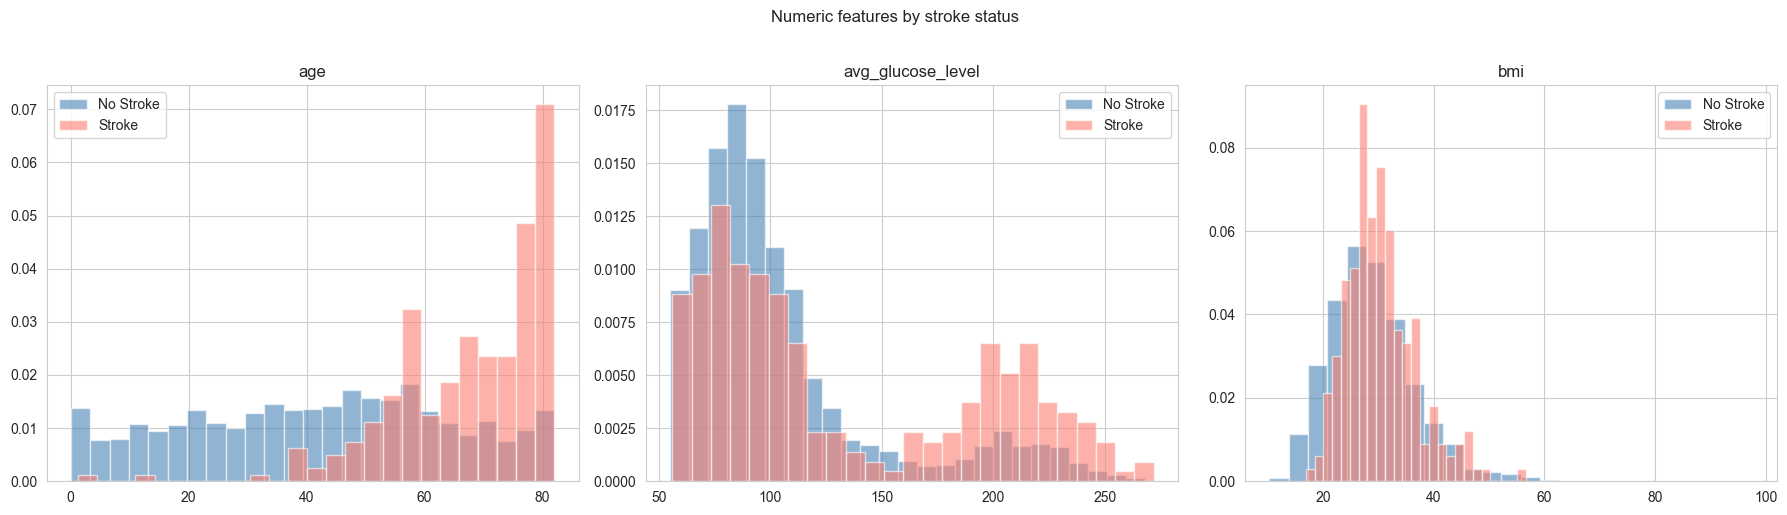

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    for s, color, label in [(0, "steelblue", "No Stroke"), (1, "salmon", "Stroke")]:
        sub = df[df["stroke"] == s][col].dropna()
        axes[i].hist(sub, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col); axes[i].legend()
plt.suptitle("Numeric features by stroke status", y=1.02)
plt.tight_layout(); plt.show()

/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_70282/3536763459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="stroke", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_70282/3536763459.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Stroke", "Stroke"])


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_70282/3536763459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="stroke", y=col, data=df, palette="Set2", ax=axes[i])


/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_70282/3536763459.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Stroke", "Stroke"])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_70282/3536763459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="stroke", y=col, data=df, palette="Set2", ax=axes[i])
/var/folders/3t/st_qgzrd3957m1htwzrz0pkc0000gn/T/ipykernel_70282/3536763459.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Stroke", "Stroke"])


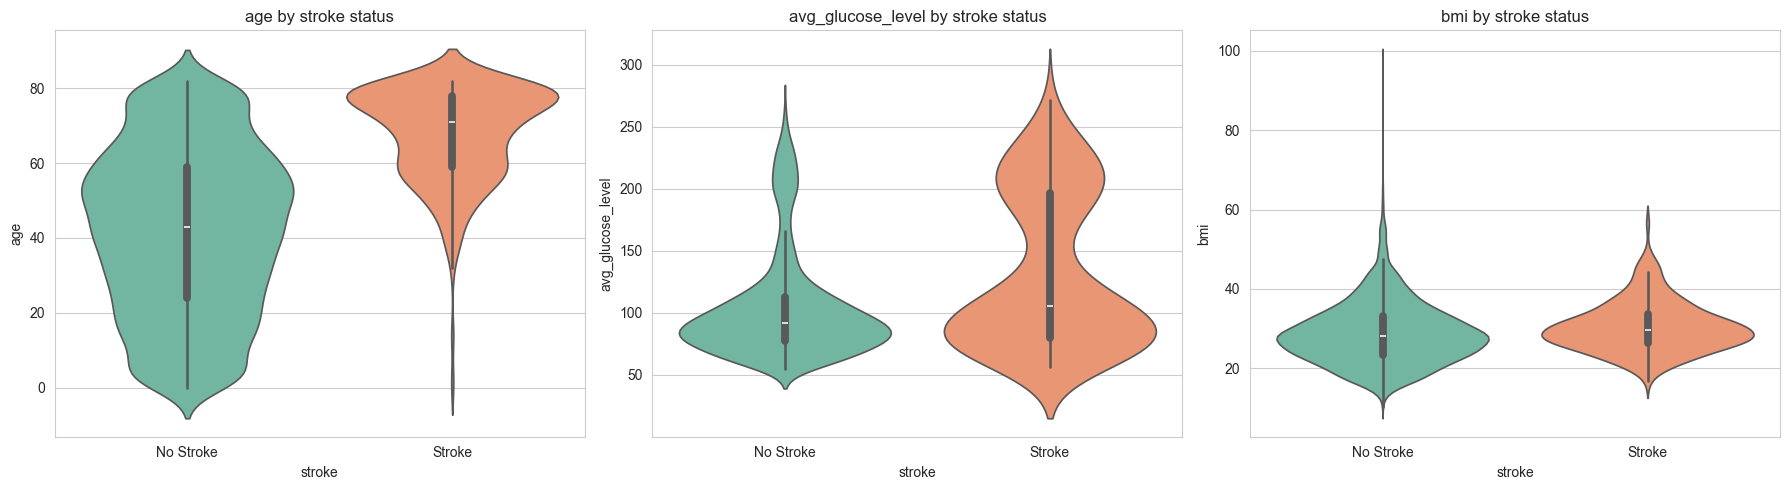

Mean by stroke status:
          age  avg_glucose_level    bmi
stroke                                 
0       41.97             104.80  28.82
1       67.73             132.54  30.47


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    sns.violinplot(x="stroke", y=col, data=df, palette="Set2", ax=axes[i])
    axes[i].set_xticklabels(["No Stroke", "Stroke"])
    axes[i].set_title(f"{col} by stroke status")
plt.tight_layout(); plt.show()

print("Mean by stroke status:")
print(df.groupby("stroke")[num_features].mean().round(2))

## 9. Bivariate — Categorical Features vs Stroke

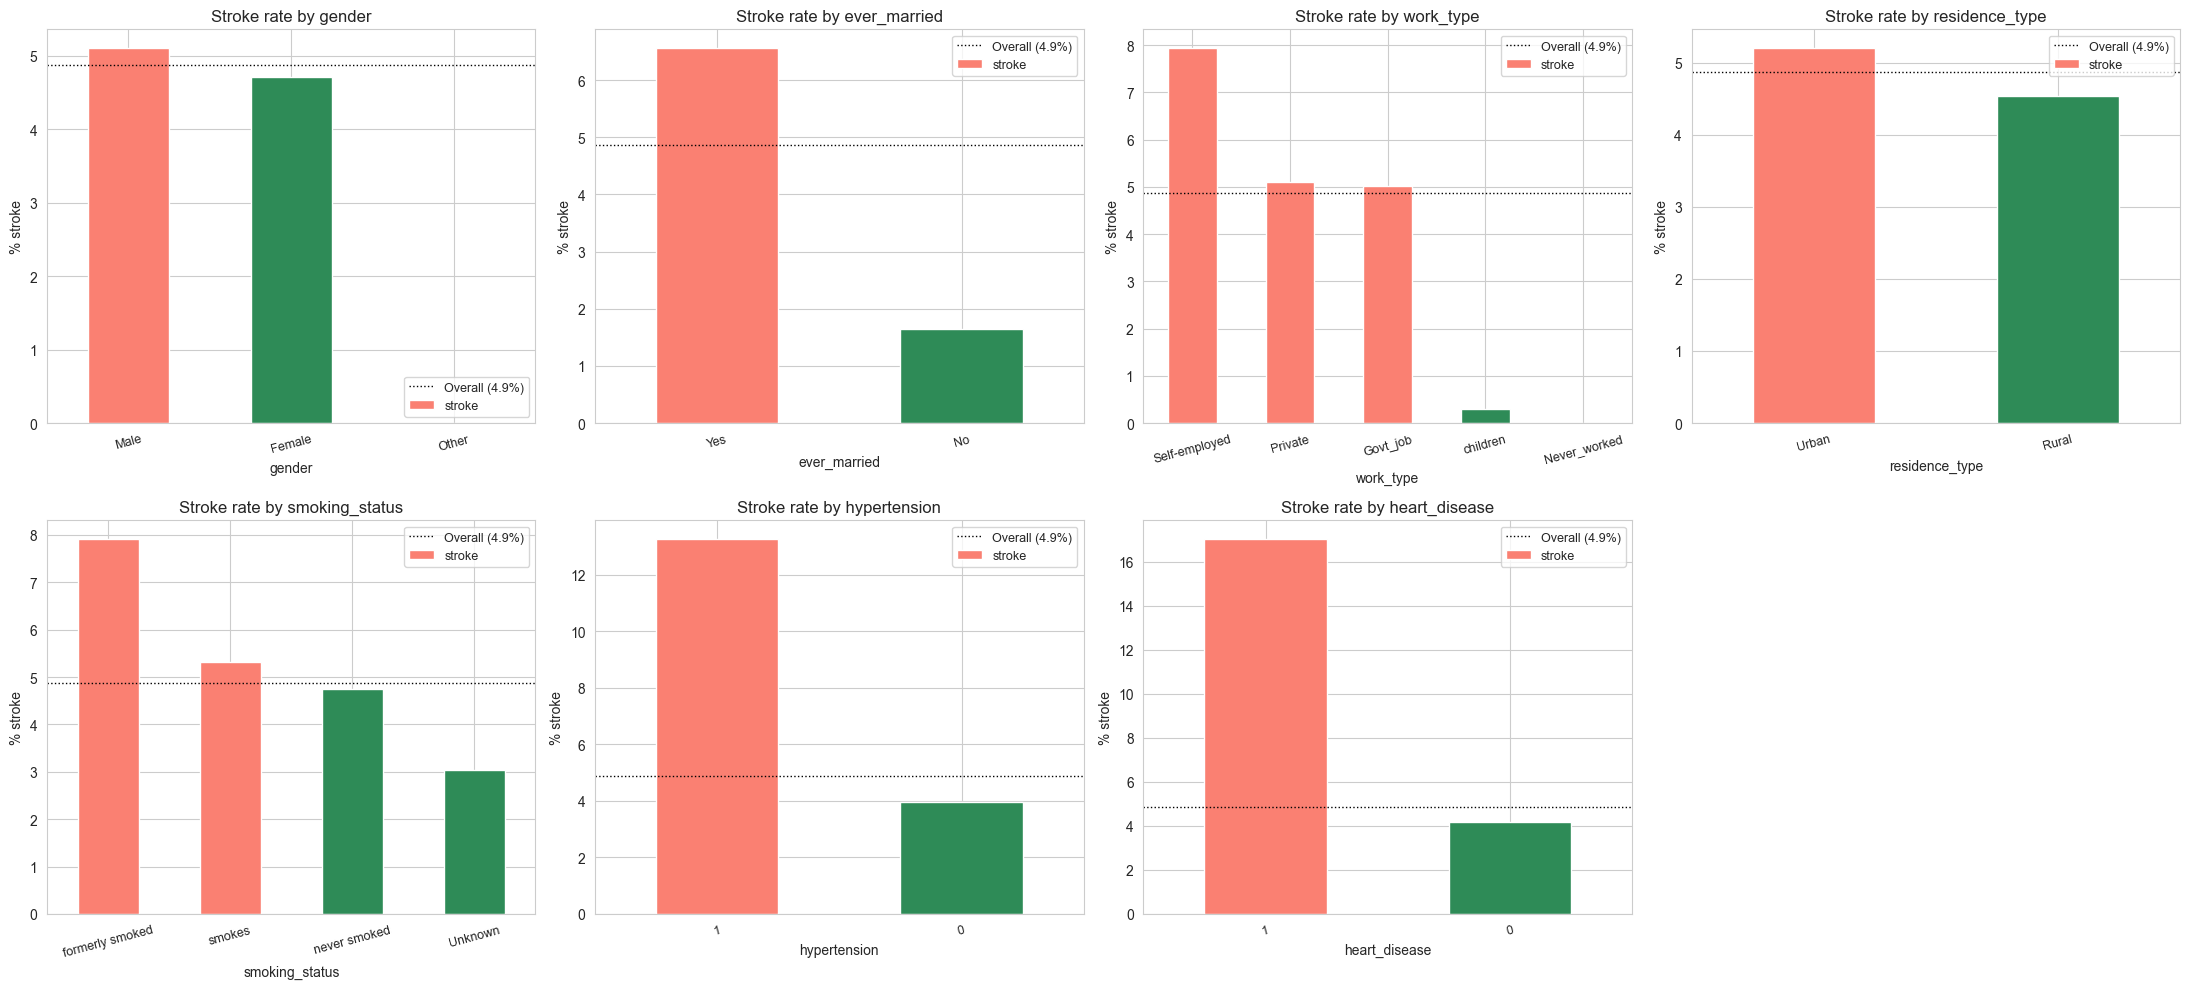

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    rate = df.groupby(col)["stroke"].mean() * 100
    rate.sort_values(ascending=False).plot(
        kind="bar",
        color=["salmon" if r > df["stroke"].mean()*100 else "seagreen" for r in rate.sort_values(ascending=False)],
        ax=axes[i])
    axes[i].axhline(df["stroke"].mean()*100, color="black", linestyle=":", linewidth=1, label=f"Overall ({df['stroke'].mean()*100:.1f}%)")
    axes[i].set_title(f"Stroke rate by {col}")
    axes[i].set_ylabel("% stroke")
    axes[i].tick_params(axis="x", labelsize=9, rotation=15)
    axes[i].legend(fontsize=9)
for j in range(len(cat_features), len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## 10. Correlation Analysis (numeric / binary features)

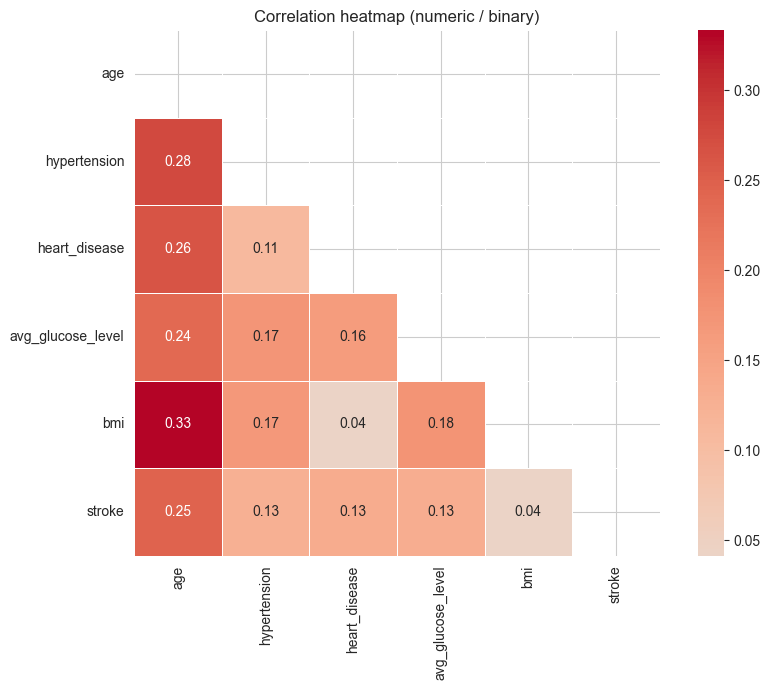

In [13]:
num_bin = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke"]
plt.figure(figsize=(9, 7))
corr = df[num_bin].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation heatmap (numeric / binary)")
plt.tight_layout(); plt.show()

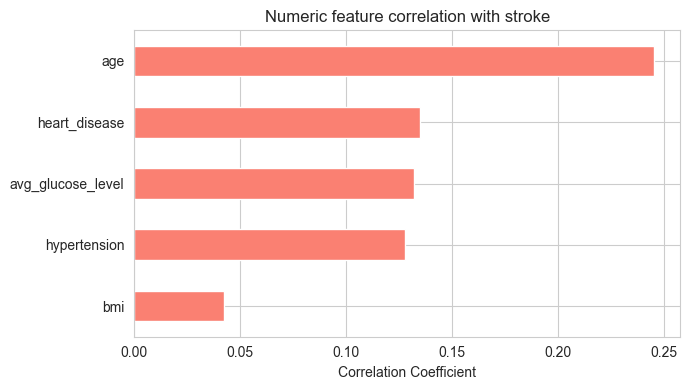

age                  0.245
heart_disease        0.135
avg_glucose_level    0.132
hypertension         0.128
bmi                  0.042
Name: stroke, dtype: float64


In [14]:
target_corr = df[num_bin].corr()["stroke"].drop("stroke").sort_values(ascending=False)
plt.figure(figsize=(7, 4))
target_corr.plot(kind="barh",
                 color=["salmon" if x > 0 else "steelblue" for x in target_corr])
plt.title("Numeric feature correlation with stroke")
plt.xlabel("Correlation Coefficient"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print(target_corr.round(3))

## 11. Age & Glucose Deep-Dive

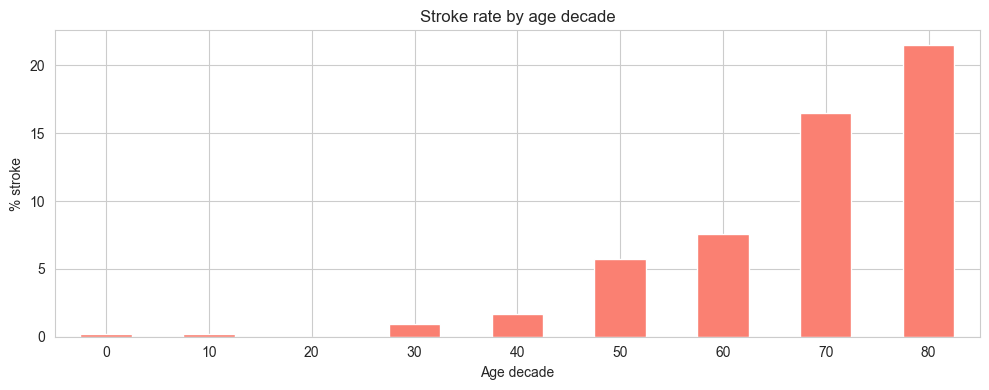

age_decade
0      0.21
10     0.20
20     0.00
30     0.92
40     1.64
50     5.76
60     7.57
70    16.52
80    21.51
Name: stroke, dtype: float64

Stroke rate by glucose category:
  normal (<100)            : 3.58% (n=3131)
  prediabetic (100-125)    : 3.78% (n=979)
  diabetic (>=125)         : 10.00% (n=1000)


In [15]:
# Stroke rate by age decade
df["age_decade"] = (df["age"] // 10 * 10).astype(int)
age_rate = df.groupby("age_decade")["stroke"].mean() * 100
plt.figure(figsize=(10, 4))
age_rate.plot(kind="bar", color="salmon")
plt.title("Stroke rate by age decade")
plt.ylabel("% stroke"); plt.xlabel("Age decade")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(age_rate.round(2))

# Stroke rate by glucose category
print("\nStroke rate by glucose category:")
for label, lo, hi in [("normal (<100)", 0, 100), ("prediabetic (100-125)", 100, 125), ("diabetic (>=125)", 125, 1000)]:
    sub = df[(df["avg_glucose_level"]>=lo) & (df["avg_glucose_level"]<hi)]
    print(f"  {label:25s}: {sub['stroke'].mean()*100:.2f}% (n={len(sub)})")

## 12. Pair Plot — Age, BMI, Glucose

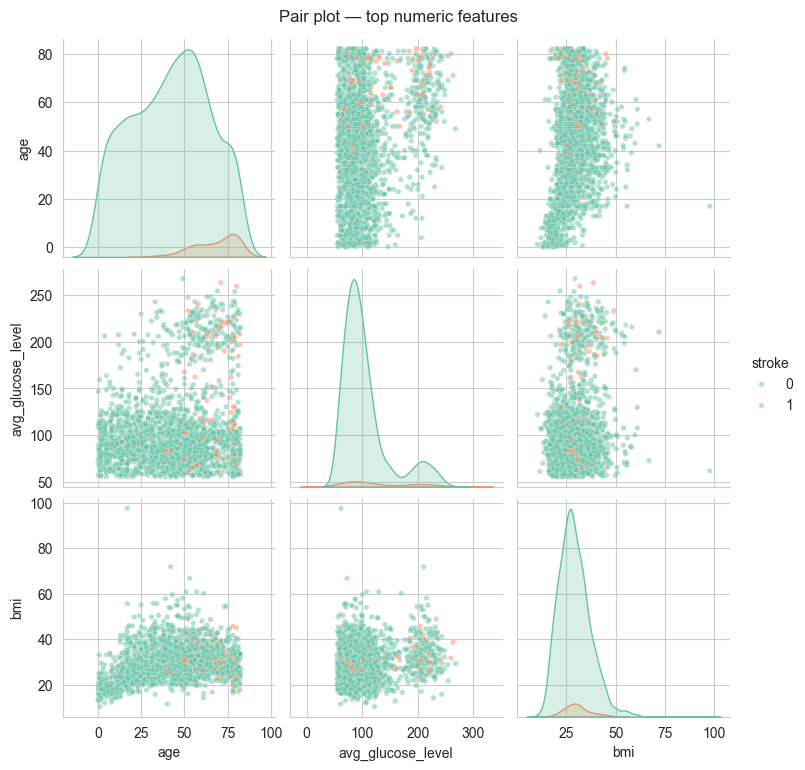

In [16]:
sample = df.dropna(subset=["bmi"]).sample(n=min(2000, len(df)), random_state=42)
sns.pairplot(sample[["age","avg_glucose_level","bmi","stroke"]],
             hue="stroke", palette="Set2", diag_kind="kde",
             plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Pair plot — top numeric features", y=1.02)
plt.show()

## 13. Key EDA Findings

| # | Finding |
|---|--------|
| 1 | **Severe class imbalance**: only **4.9%** of patients had a stroke — F1 / recall on the positive class are the right metrics |
| 2 | **Age is the dominant predictor** (r ≈ 0.245) — stroke rate climbs from ~0% under 30 to >10% in the 70+ decade |
| 3 | **Hypertension and heart disease** roughly **double** the stroke rate vs the baseline |
| 4 | **Glucose level** correlates positively (r ≈ 0.13) — diabetic patients (>125) have 2-3× the stroke rate of normal-glucose patients |
| 5 | **BMI has 201 missing values** (~3.9%) — needs imputation. Median is reasonable. |
| 6 | **Smoking status `formerly smoked`** has the highest stroke rate, even more than current smokers — an age-confounding effect |
| 7 | **`gender=Other` has only 1 row** — drop it before one-hot encoding to avoid a singleton dummy |
| 8 | **Children (work_type=children, age<18) effectively never have a stroke** in this sample — the model needs to capture this age cliff |